Iniciando a inspeção do dataset COCO...

[TRAIN] Inspecionando: ISIC_0010187.jpg
[VALID] Inspecionando: ISIC_0019723.jpg
[TEST] Inspecionando: ISIC_0036075.jpg


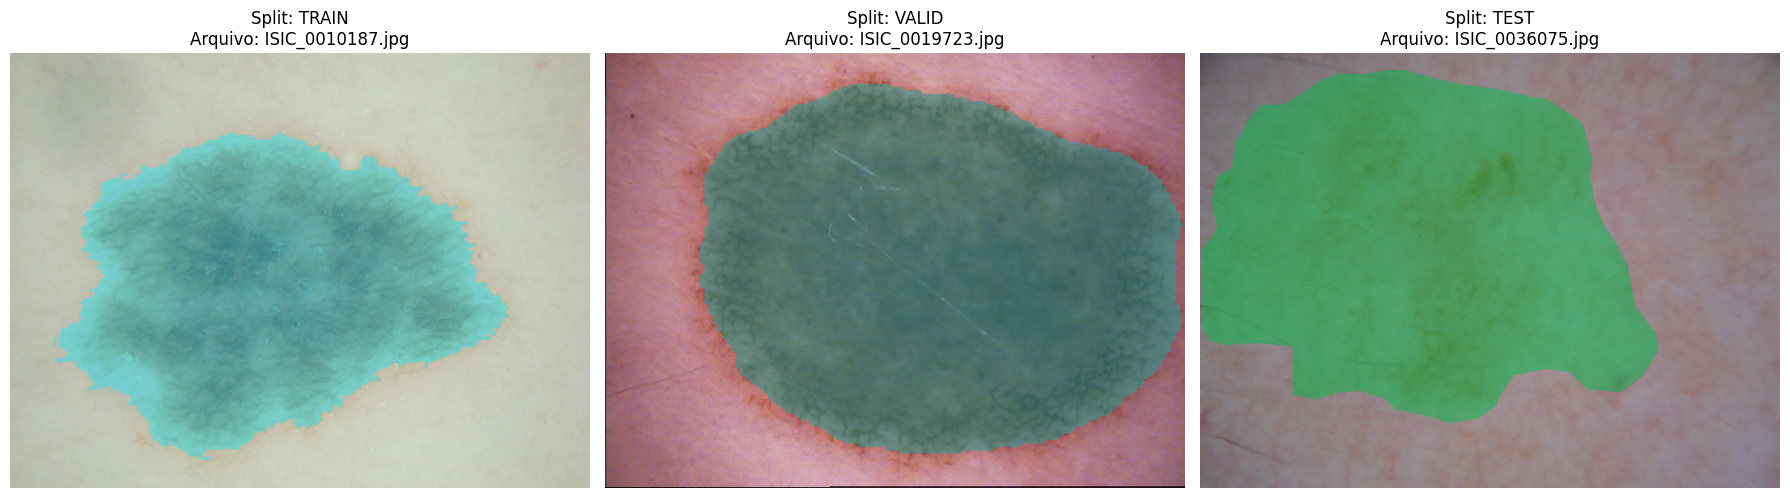

In [5]:
import os
import random
from contextlib import redirect_stdout

import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO


def inspect_coco_dataset(base_dir: str) -> None:
    """
    Gera uma visualização com 3 painéis (Treino, Validação, Teste) mostrando
    imagens aleatórias com suas respectivas máscaras de segmentação.
    """
    splits = ['train', 'valid', 'test']
    
    # Prepara a figura (plot) com 3 espaços dispostos lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, split in enumerate(splits):
        ann_file = os.path.join(base_dir, split, '_annotations.coco.json')
        img_dir = os.path.join(base_dir, split)
        
        # Verifica se o arquivo JSON daquele split existe antes de tentar carregar
        if not os.path.exists(ann_file):
            axes[idx].set_title(f"{split.upper()}: JSON não encontrado", color='red')
            axes[idx].axis('off')
            continue

        # Inicializa a API do COCO silenciosamente (evitando poluir o terminal)
        with open(os.devnull, 'w') as f, redirect_stdout(f):
            coco = COCO(ann_file)
            
        img_ids = coco.getImgIds()
        
        # Lida com casos em que o JSON existe mas não contém imagens anotadas
        if not img_ids:
            axes[idx].set_title(f"{split.upper()}: Nenhuma imagem anotada", color='red')
            axes[idx].axis('off')
            continue

        # Seleciona uma imagem aleatória do dataset do split atual
        random_img_id = random.choice(img_ids)
        img_data = coco.loadImgs(random_img_id)[0]
        
        # Extrai apenas o nome do arquivo para contornar eventuais problemas de caminho
        just_the_name = os.path.basename(img_data['file_name'])
        print(f"[{split.upper()}] Inspecionando: {just_the_name}")

        # Carrega a imagem do disco
        img_path = os.path.join(img_dir, just_the_name)
        image = cv2.imread(img_path)
        
        # Trata o caso de a imagem estar corrompida ou não existir fisicamente na pasta
        if image is None:
            axes[idx].set_title(f"{split.upper()}\nErro ao carregar imagem", color='red')
            axes[idx].axis('off')
            continue
            
        # Converte o padrão BGR (usado pelo OpenCV) para o padrão RGB (usado pelo Matplotlib)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Busca as anotações de segmentação referentes à imagem carregada
        ann_ids = coco.getAnnIds(imgIds=img_data['id'])
        anns = coco.loadAnns(ann_ids)

        # Plota a imagem "nua" no respectivo painel (subplot)
        axes[idx].imshow(image)
        axes[idx].axis('off')
        
        # Define o foco do Matplotlib para o painel atual e desenha a máscara por cima da imagem
        plt.sca(axes[idx])
        coco.showAnns(anns) 

        # Adiciona o título no painel com o nome da imagem inspecionada
        axes[idx].set_title(f"Split: {split.upper()}\nArquivo: {just_the_name}")

    # Ajusta os espaçamentos automáticos para não sobrepor textos e exibe o gráfico final
    plt.tight_layout()
    plt.show()


def main() -> None:
    """
    Função principal que define o caminho do dataset e chama a rotina de inspeção.
    """
    base_dir = '/home/antoniovinicius/projects/sandbox_sam3/datasets/isic_2018_task1_coco'
    
    print("Iniciando a inspeção do dataset COCO...\n")
    inspect_coco_dataset(base_dir)

if __name__ == '__main__':
    main()